In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve, make_scorer, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

from src.eda import load_data
from src.preprocessing import add_aggregate_usage_features, add_usage_share_features, add_usage_composition_share_features
from src.preprocessing import add_customer_service_and_interaction_features, get_df_engineered
from src.modeling import train_model
from utils.modeling import save_estimator

In [2]:
df = load_data()

# drop non-informative columns
df = df.drop(columns=["state"])
df['area_code'] = df['area_code'].cat.codes
df['international_plan'] = df['international_plan'].cat.codes
df['voice_mail_plan'] = df['voice_mail_plan'].cat.codes
df

,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,128,1,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,1,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,1,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,84,0,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,1,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,79,1,0,0,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2,False
2662,192,1,0,1,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
2663,68,1,0,0,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
2664,28,2,0,0,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False


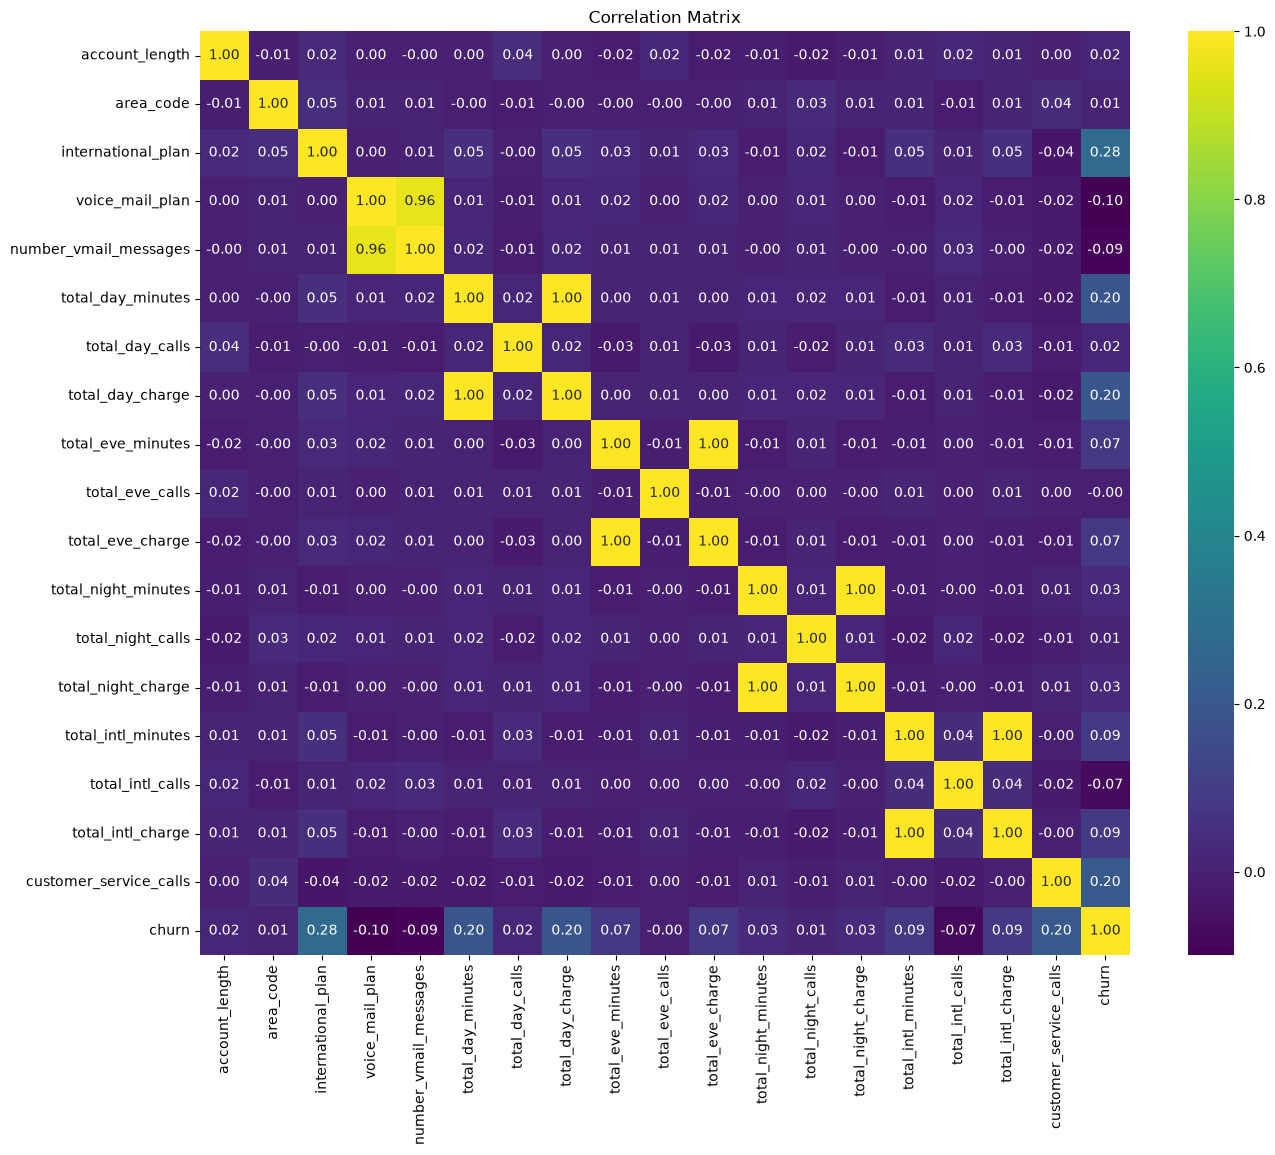

In [3]:
_, ax = plt.subplots(figsize=(15, 12))

sns.heatmap(
    data=df.corr(),
    annot=True,
    cmap="viridis",
    fmt=".2f",
    ax=ax,
)

ax.set_title("Correlation Matrix")
plt.show()

In [4]:
# loading data
X = df.drop(columns=['churn'])
y = df['churn']

print(f"X.shape = {X.shape}")
print(f"y.shape = {y.shape} -> binary\n")

# train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Traning set shape = {X_train.shape}")
print(f"Validation set shape = {X_val.shape}")
print("--" * 30)

# standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# traning baseline models
log_reg = LogisticRegression(random_state=42)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
knn = KNeighborsClassifier()
svm = SVC(random_state=42)
naive_bayes = GaussianNB()
rf = RandomForestClassifier(random_state=42)

models = [log_reg, dt, knn, svm, naive_bayes, rf]
model_names = ['log_reg', 'dt', 'knn', 'svm', 'naive_bayes', 'rf']

for model, name in zip(models, model_names):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    print(f"{name} train f1-score = {f1_score(y_val, y_pred, average='macro')}")
    print(f"{name} val f1-score = {f1_score(y_val, y_pred, average='macro')}\n")

X.shape = (2666, 18)
y.shape = (2666,) -> binary

Traning set shape = (2132, 18)
Validation set shape = (534, 18)
------------------------------------------------------------
log_reg train f1-score = 0.6209653317393903
log_reg val f1-score = 0.6209653317393903

dt train f1-score = 0.7925407925407926
dt val f1-score = 0.7925407925407926

knn train f1-score = 0.6933547968030727
knn val f1-score = 0.6933547968030727

svm train f1-score = 0.7552374019250991
svm val f1-score = 0.7552374019250991

naive_bayes train f1-score = 0.689760348583878
naive_bayes val f1-score = 0.689760348583878

rf train f1-score = 0.8840577379277069
rf val f1-score = 0.8840577379277069



In [5]:
for model, model_name in zip(models, model_names):
    pipe = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('clf', model)
    ])
    f1_cv_scores = cross_val_score(
        estimator=pipe,
        X=X,
        y=y,
        cv=5,
        scoring=make_scorer(f1_score, greater_is_better=True),
        n_jobs=-1
	)
    auc_cv_scores = cross_val_score(
        estimator=pipe,
        X=X,
        y=y,
        cv=5,
        scoring=make_scorer(roc_auc_score, greater_is_better=True),
        n_jobs=-1
	)
    print(f"Model: {model_name}, CV F1-score: {f1_cv_scores.mean()} ± {f1_cv_scores.std()}")
    print(f"Model: {model_name}, CV AUC: {auc_cv_scores.mean()} ± {auc_cv_scores.std()}\n")

Model: log_reg, CV F1-score: 0.318822216946113 ± 0.024449302977923696
Model: log_reg, CV AUC: 0.5965580034001087 ± 0.010214102485353904

Model: dt, CV F1-score: 0.7423050693444128 ± 0.021498565814864017
Model: dt, CV AUC: 0.8300097709308234 ± 0.01682210299058864

Model: knn, CV F1-score: 0.4766071530136865 ± 0.059671666471993096
Model: knn, CV AUC: 0.6638648632069685 ± 0.027593266731616065

Model: svm, CV F1-score: 0.6024831104014605 ± 0.04011345620181795
Model: svm, CV AUC: 0.727341386683492 ± 0.023082829575880936

Model: naive_bayes, CV F1-score: 0.5244932686532873 ± 0.0509040258963045
Model: naive_bayes, CV AUC: 0.7211543281280124 ± 0.027236492845077717

Model: rf, CV F1-score: 0.816177506883127 ± 0.0471998712196758
Model: rf, CV AUC: 0.8570430446746237 ± 0.031131247820569877



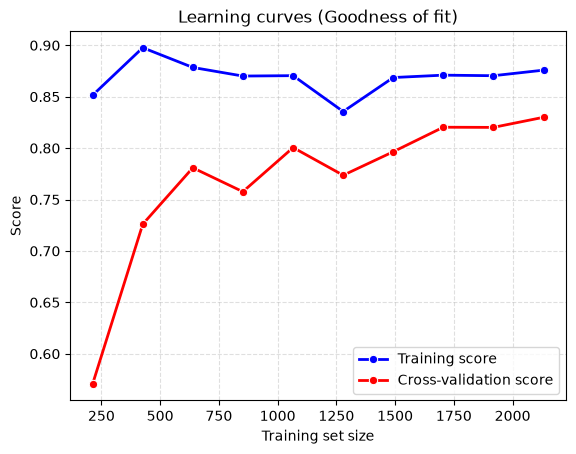

In [6]:
# plot learning curves
train_sizes, train_scores, test_scores = learning_curve(
    estimator=dt,
    X=X,
    y=y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring=make_scorer(roc_auc_score, greater_is_better=True),
    n_jobs=-1,
)

sns.lineplot(
    x=train_sizes,
    y=train_scores.mean(axis=1),
    label="Training score",
    color="b",
    lw=2,
    marker="o",
)
sns.lineplot(
    x=train_sizes,
    y=test_scores.mean(axis=1),
    label="Cross-validation score",
    color="r",
    lw=2,
    marker="o",
)

plt.title("Learning curves (Goodness of fit)")
plt.xlabel("Training set size")
plt.ylabel("Score")
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.4)

In [7]:
# evaluate decision tree model
dt.fit(X_train_scaled, y_train)

y_pred = dt.predict(X_val_scaled)

acc = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred)
dt_cm = confusion_matrix(y_val, y_pred)

print(f"Accuracy: {acc:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")

Accuracy: 0.91
Precision: 0.79
Recall: 0.53
F1-score: 0.64
ROC-AUC: 0.75


In [8]:
# evaluate random forest model
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_val_scaled)

acc = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred)
rf_cm = confusion_matrix(y_val, y_pred)

print(f"Accuracy: {acc:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")

Accuracy: 0.95
Precision: 0.98
Recall: 0.67
F1-score: 0.80
ROC-AUC: 0.83


<Axes: ylabel='None'>

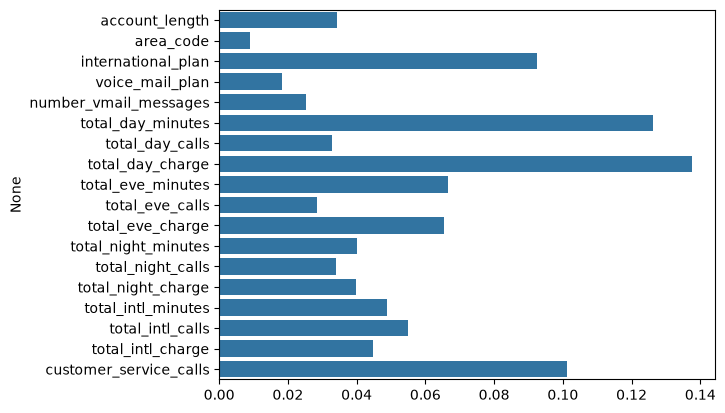

In [9]:
# feature importance
sns.barplot(
    x=rf.feature_importances_,
    y=X.columns,
)

In [10]:
# train and evaluate a xgboost model as a baseline
bst = XGBClassifier(n_estimators=100, objective="binary:logistic")
bst.fit(X_train_scaled, y_train)

y_pred = bst.predict(X_val_scaled)

acc = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred)
rf_cm = confusion_matrix(y_val, y_pred)
bst_cm = confusion_matrix(y_val, y_pred)

print(f"Accuracy: {acc:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")

Accuracy: 0.95
Precision: 0.95
Recall: 0.71
F1-score: 0.81
ROC-AUC: 0.85


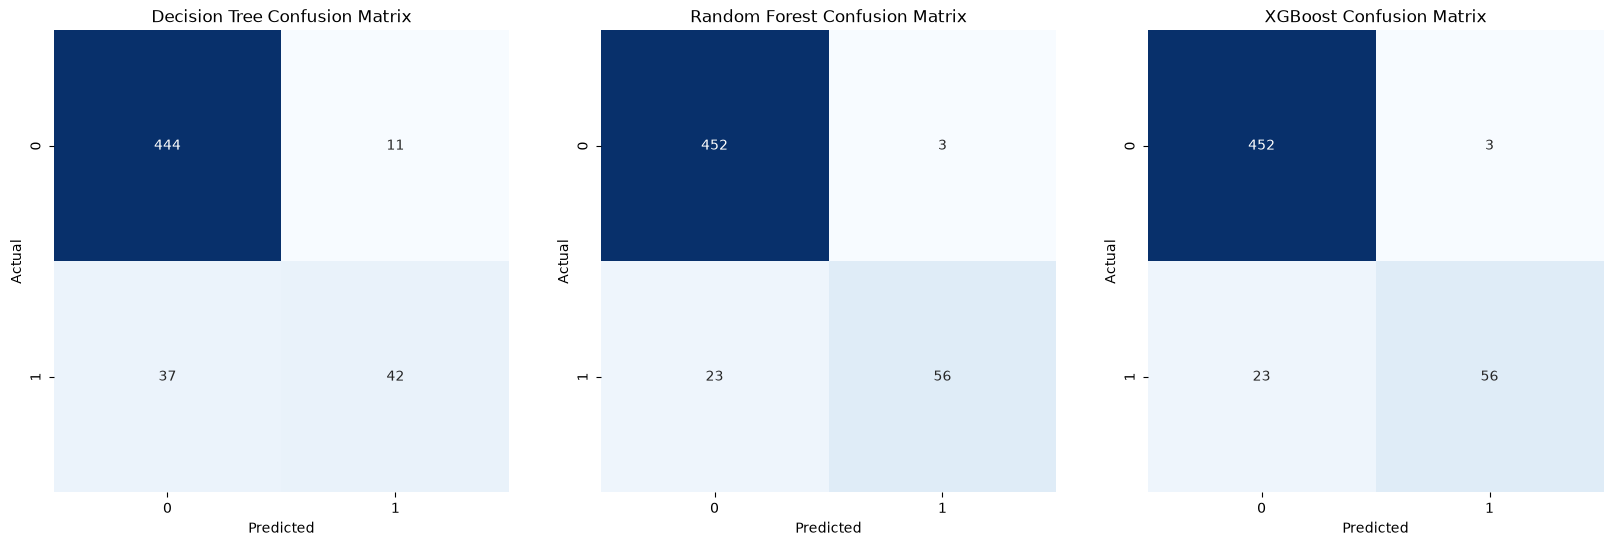

In [11]:
# compare the performance of different models using confusion matrix
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
sns.heatmap(
    data=dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=ax1,
)
sns.heatmap(
    data=rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=ax2,
)
sns.heatmap(
    data=bst_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=ax3,
)

ax1.set(
    title="Decision Tree Confusion Matrix",
    xlabel="Predicted",
    ylabel="Actual",
)
ax2.set(
    title="Random Forest Confusion Matrix",
    xlabel="Predicted",
    ylabel="Actual",
)
ax3.set(
    title="XGBoost Confusion Matrix",
    xlabel="Predicted",
    ylabel="Actual",
)

plt.show()

In [12]:
def train_and_evaluate_models(df: pd.DataFrame) -> None:
	"""
	This function trains and evaluates three kinds of models: Decision Tree,
	Random Forest, and XGBoost on the given dataframe.

	:param df: Dataframe containing the original data.
	:return: None
	"""
	# define models and model names
	dt = DecisionTreeClassifier(random_state=42)
	rf = RandomForestClassifier(oob_score=True, random_state=42, n_jobs=-1)
	bst = XGBClassifier(random_state=42, n_jobs=-1)
	models = [dt, rf, bst]
	model_names = ['Decision Tree', 'Random Forest', 'XGBoost']

	# load data
	X, y = df.drop(columns=['churn']), df['churn']

	scaler = StandardScaler()
	X_scaled = scaler.fit_transform(X) # standardize the features

	kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

	# evaluate models
	for model, name in zip(models, model_names):
		model.fit(X_scaled, y)
		auc_cv_scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='roc_auc')
		precision_cv_scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='precision')
		recall_cv_scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='recall')
		f1_cv_scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='f1')
		accuracy_cv_scores = cross_val_score(model, X_scaled, y, cv=kfold, scoring='accuracy')

		print(f"Model: {name}, AUC CV Score: {auc_cv_scores.mean()} ± {auc_cv_scores.std()}")
		print(f"Model: {name}, Precision CV Score: {precision_cv_scores.mean()} ± {precision_cv_scores.std()}")
		print(f"Model: {name}, Recall CV Score: {recall_cv_scores.mean()} ± {recall_cv_scores.std()}")
		print(f"Model: {name}, F1 CV Score: {f1_cv_scores.mean()} ± {f1_cv_scores.std()}")
		print(f"Model: {name}, Accuracy CV Score: {accuracy_cv_scores.mean()} ± {accuracy_cv_scores.std()}")
		print("--" * 50)

train_and_evaluate_models(df)

Model: Decision Tree, AUC CV Score: 0.825373792873793 ± 0.014326736639192286
Model: Decision Tree, Precision CV Score: 0.6632414004914005 ± 0.05699210447008072
Model: Decision Tree, Recall CV Score: 0.713952713952714 ± 0.029363945950464165
Model: Decision Tree, F1 CV Score: 0.6858819519025294 ± 0.030991911227189528
Model: Decision Tree, Accuracy CV Score: 0.9043573581803234 ± 0.013266215461014289
----------------------------------------------------------------------------------------------------
Model: Random Forest, AUC CV Score: 0.9120704093477373 ± 0.010819298375286258
Model: Random Forest, Precision CV Score: 0.9301013256707418 ± 0.05601705458943941
Model: Random Forest, Recall CV Score: 0.7189810189810191 ± 0.02722660085715524
Model: Random Forest, F1 CV Score: 0.8102139438463736 ± 0.03149458976475003
Model: Random Forest, Accuracy CV Score: 0.9508688716964958 ± 0.009023195759156605
---------------------------------------------------------------------------------------------------

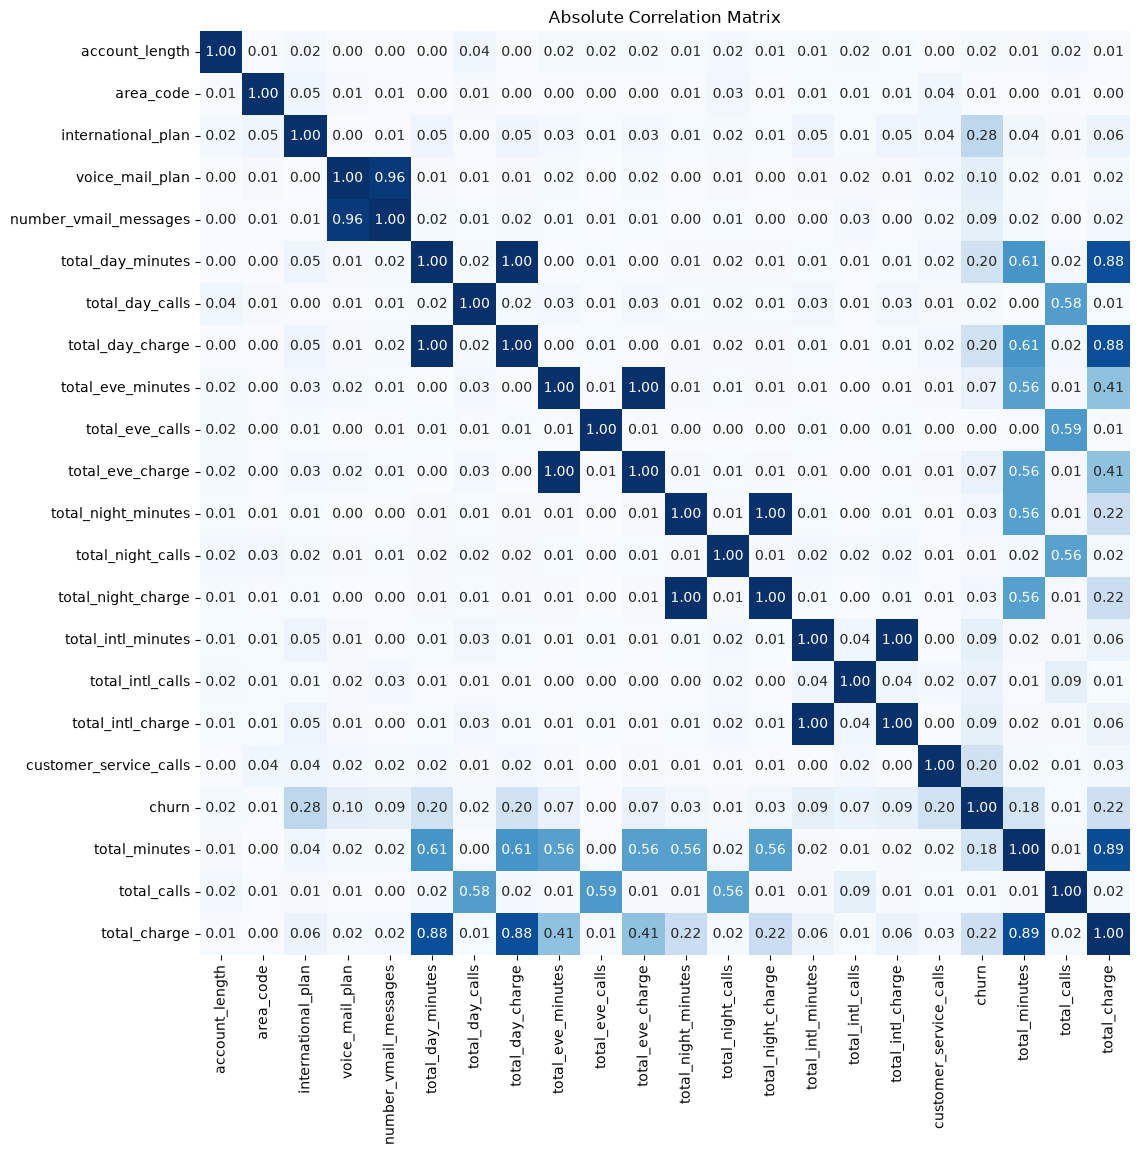

In [13]:
# add aggregate usage features to the existing dataframe
df = add_aggregate_usage_features(df)

_, ax = plt.subplots(figsize=(12, 12))

sns.heatmap(
    data=abs(df.corr()),
    cmap="Blues",
    annot=True,
    cbar=False,
    fmt=".2f",
)
plt.title("Absolute Correlation Matrix")
plt.show()

In [14]:
# train and evaluate models on the new data
train_and_evaluate_models(df)

Model: Decision Tree, AUC CV Score: 0.9040743467059256 ± 0.012367177643334858
Model: Decision Tree, Precision CV Score: 0.8059227130351225 ± 0.023774132446242394
Model: Decision Tree, Recall CV Score: 0.8428238428238428 ± 0.024678223090992185
Model: Decision Tree, F1 CV Score: 0.8236372269705603 ± 0.017968765340949558
Model: Decision Tree, Accuracy CV Score: 0.9474882475704618 ± 0.005291858226694928
----------------------------------------------------------------------------------------------------
Model: Random Forest, AUC CV Score: 0.9193168735223392 ± 0.015352154371827579
Model: Random Forest, Precision CV Score: 0.9936507936507937 ± 0.012698412698412698
Model: Random Forest, Recall CV Score: 0.82997002997003 ± 0.025726382484773276
Model: Random Forest, F1 CV Score: 0.904376828844914 ± 0.020326000544388587
Model: Random Forest, Accuracy CV Score: 0.9744974035738629 ± 0.005227539649996538
------------------------------------------------------------------------------------------------

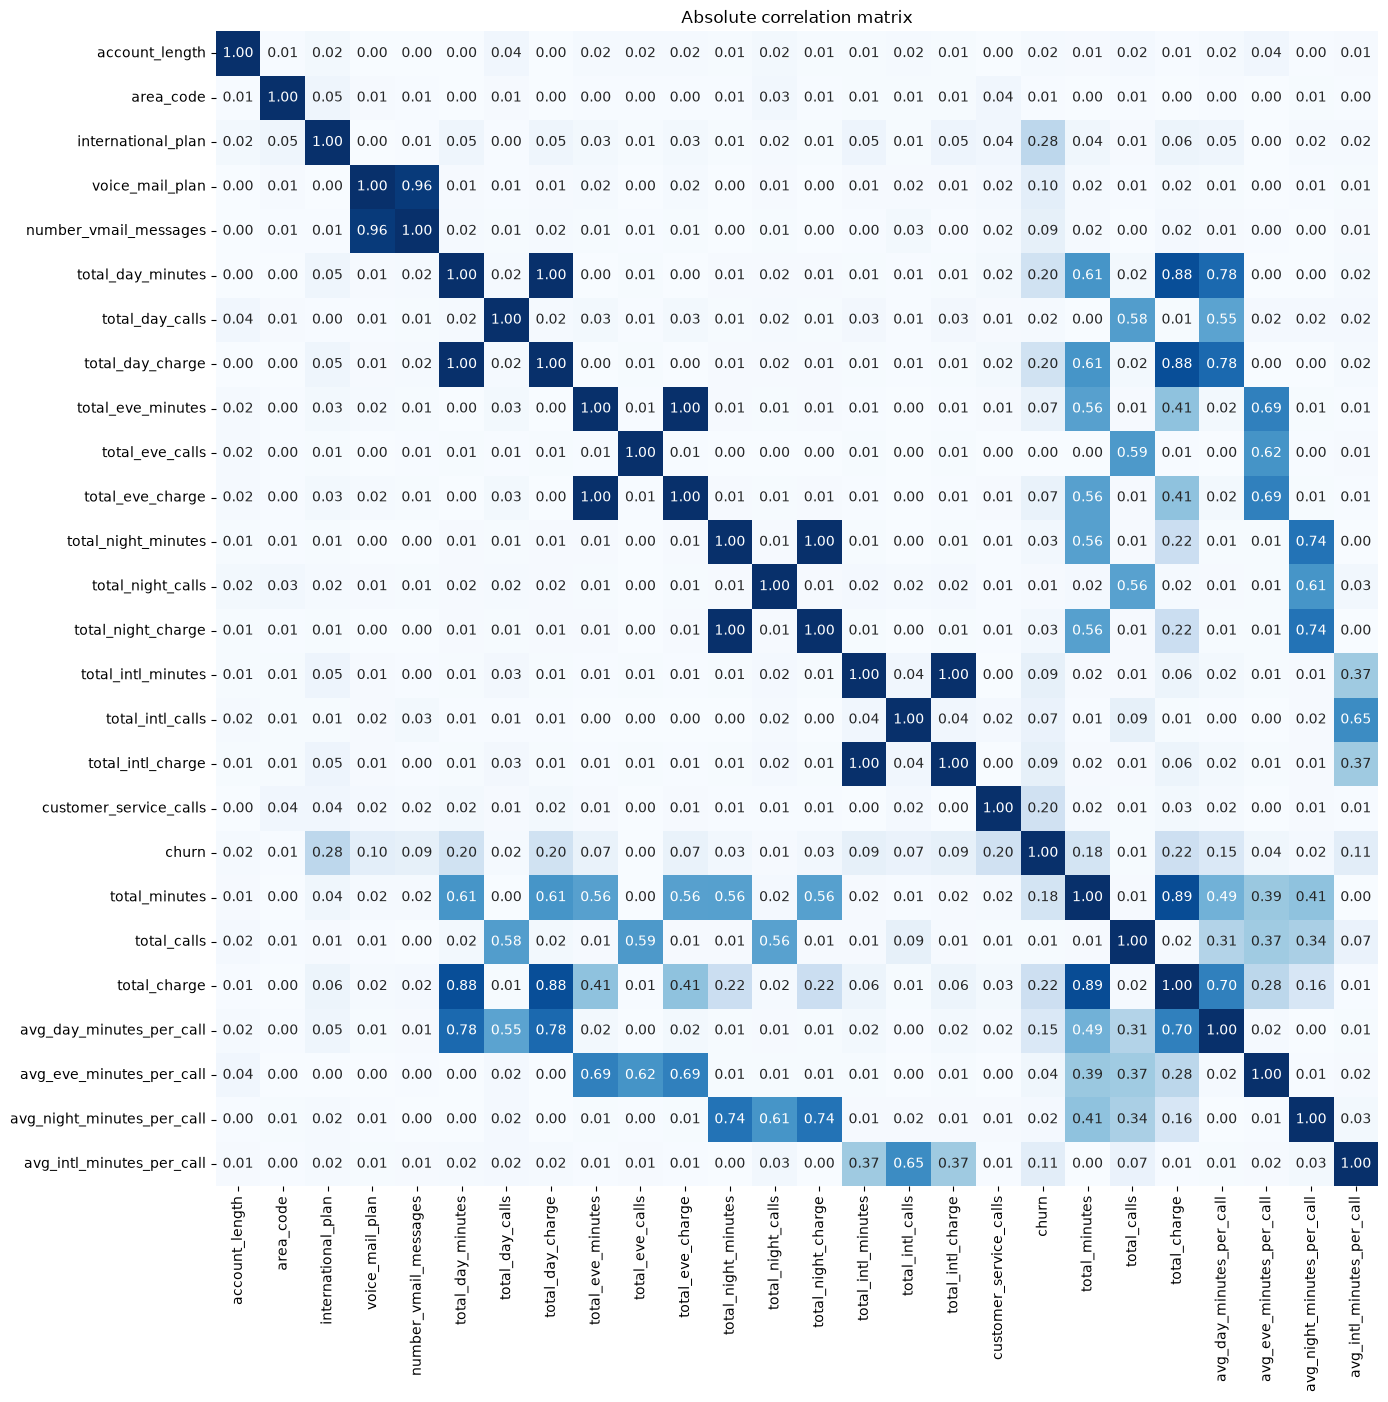

In [15]:
# add usage share features to the existing dataframe
df = add_usage_share_features(df)

_, ax = plt.subplots(figsize=(15, 15))

sns.heatmap(
    data=abs(df.corr()),
    cmap="Blues",
    annot=True,
    cbar=False,
    fmt=".2f",
)
plt.title("Absolute correlation matrix")
plt.show()

In [16]:
# train and evaluate models on the new data
train_and_evaluate_models(df)

Model: Decision Tree, AUC CV Score: 0.904530995320469 ± 0.01120519022813746
Model: Decision Tree, Precision CV Score: 0.8215303080728841 ± 0.02116828809647166
Model: Decision Tree, Recall CV Score: 0.8402264402264403 ± 0.022229511992887113
Model: Decision Tree, F1 CV Score: 0.8305257380430919 ± 0.016222730987523585
Model: Decision Tree, Accuracy CV Score: 0.9501141865351238 ± 0.004667236098643876
----------------------------------------------------------------------------------------------------
Model: Random Forest, AUC CV Score: 0.919283431930193 ± 0.010285167423156242
Model: Random Forest, Precision CV Score: 0.99375 ± 0.012499999999999999
Model: Random Forest, Recall CV Score: 0.8402597402597403 ± 0.02855652117098628
Model: Random Forest, F1 CV Score: 0.9104388338041935 ± 0.021171262519339745
Model: Random Forest, Accuracy CV Score: 0.9759976389737968 ± 0.005466739909894395
----------------------------------------------------------------------------------------------------
Model: X

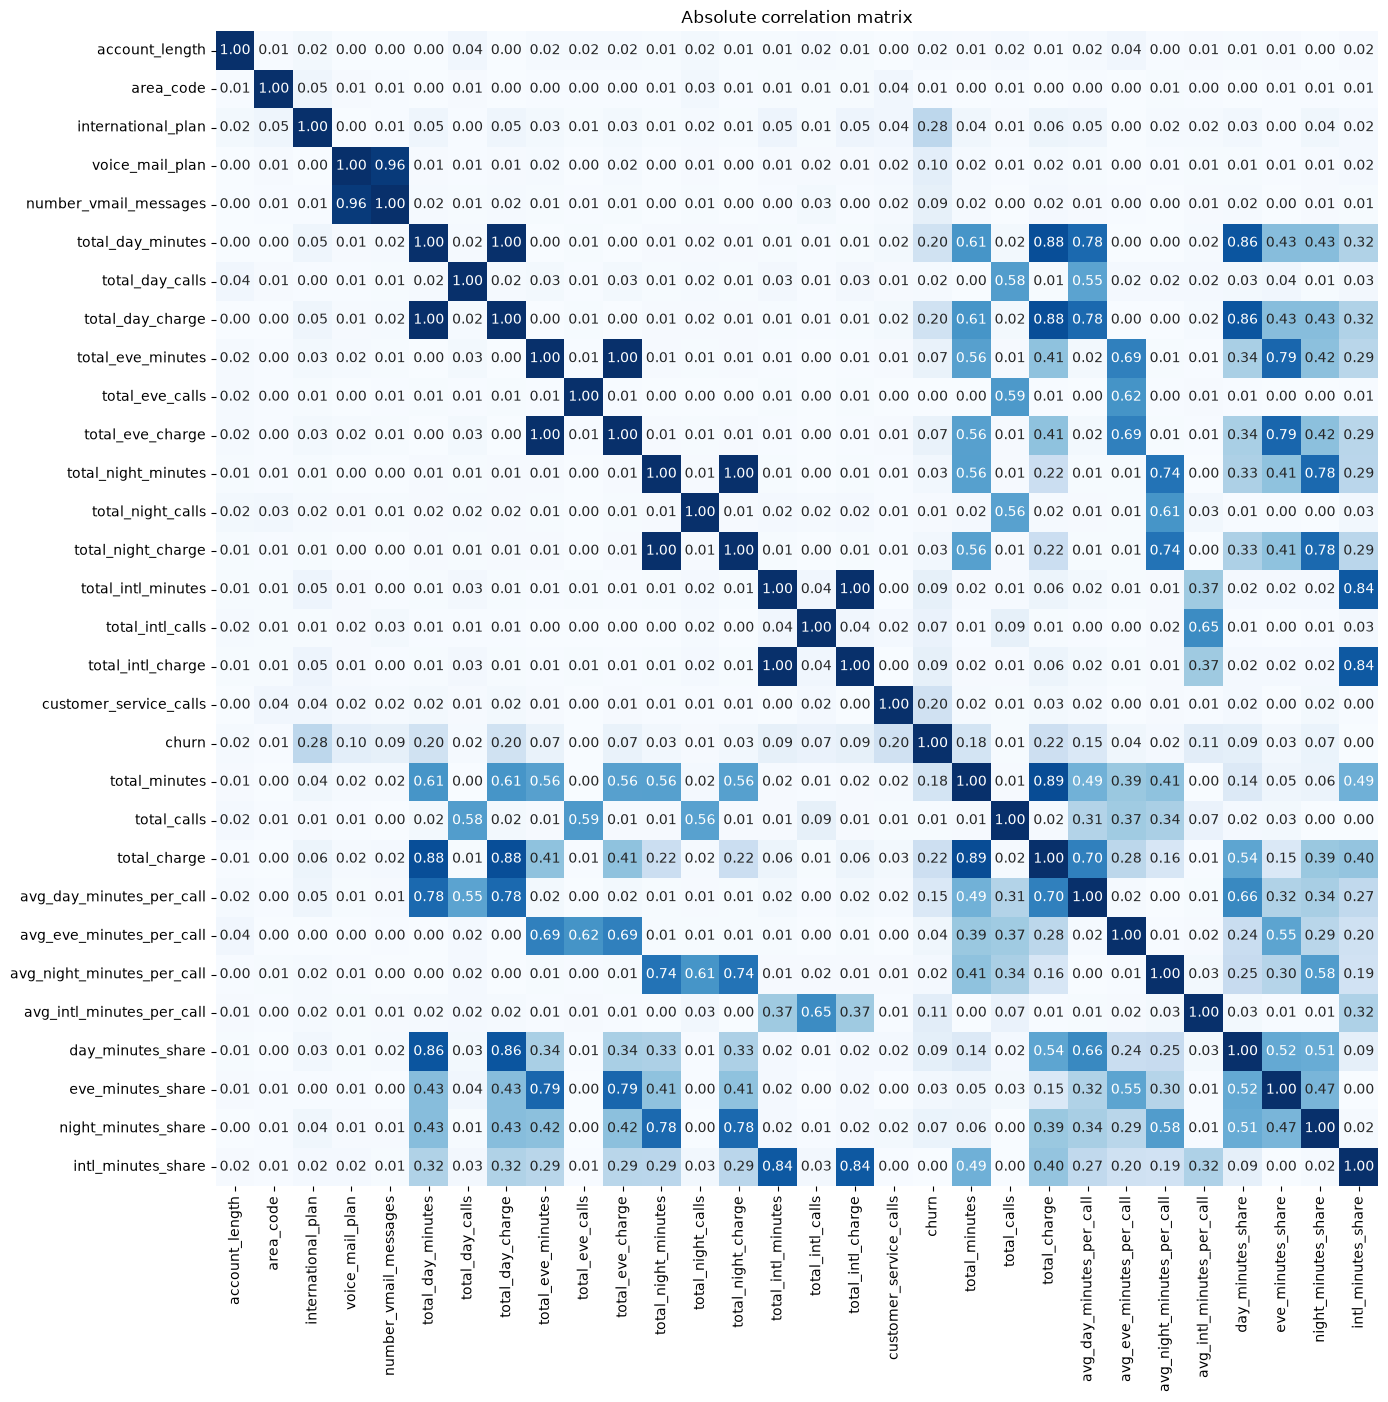

In [17]:
# add usage composition share features to the existing dataframe
df = add_usage_composition_share_features(df)

_, ax = plt.subplots(figsize=(15, 15))

sns.heatmap(
    data=abs(df.corr()),
    cmap="Blues",
    annot=True,
    cbar=False,
    fmt=".2f",
)
plt.title("Absolute correlation matrix")
plt.show()

In [18]:
# train and evaluate models on the new data
train_and_evaluate_models(df)

Model: Decision Tree, AUC CV Score: 0.9014379480168954 ± 0.012322285043375788
Model: Decision Tree, Precision CV Score: 0.7836814065271441 ± 0.03400393448661705
Model: Decision Tree, Recall CV Score: 0.8428238428238428 ± 0.024678223090992185
Model: Decision Tree, F1 CV Score: 0.8115955460953692 ± 0.02094841739381979
Model: Decision Tree, Accuracy CV Score: 0.9429840279388101 ± 0.006992557725433611
----------------------------------------------------------------------------------------------------
Model: Random Forest, AUC CV Score: 0.9170908623540202 ± 0.012103121512500245
Model: Random Forest, Precision CV Score: 0.9969696969696968 ± 0.006060606060606055
Model: Random Forest, Recall CV Score: 0.8145188145188145 ± 0.0422450002530277
Model: Random Forest, F1 CV Score: 0.8958983451536643 ± 0.026113291547400365
Model: Random Forest, Accuracy CV Score: 0.972622636338723 ± 0.006090939769558225
--------------------------------------------------------------------------------------------------

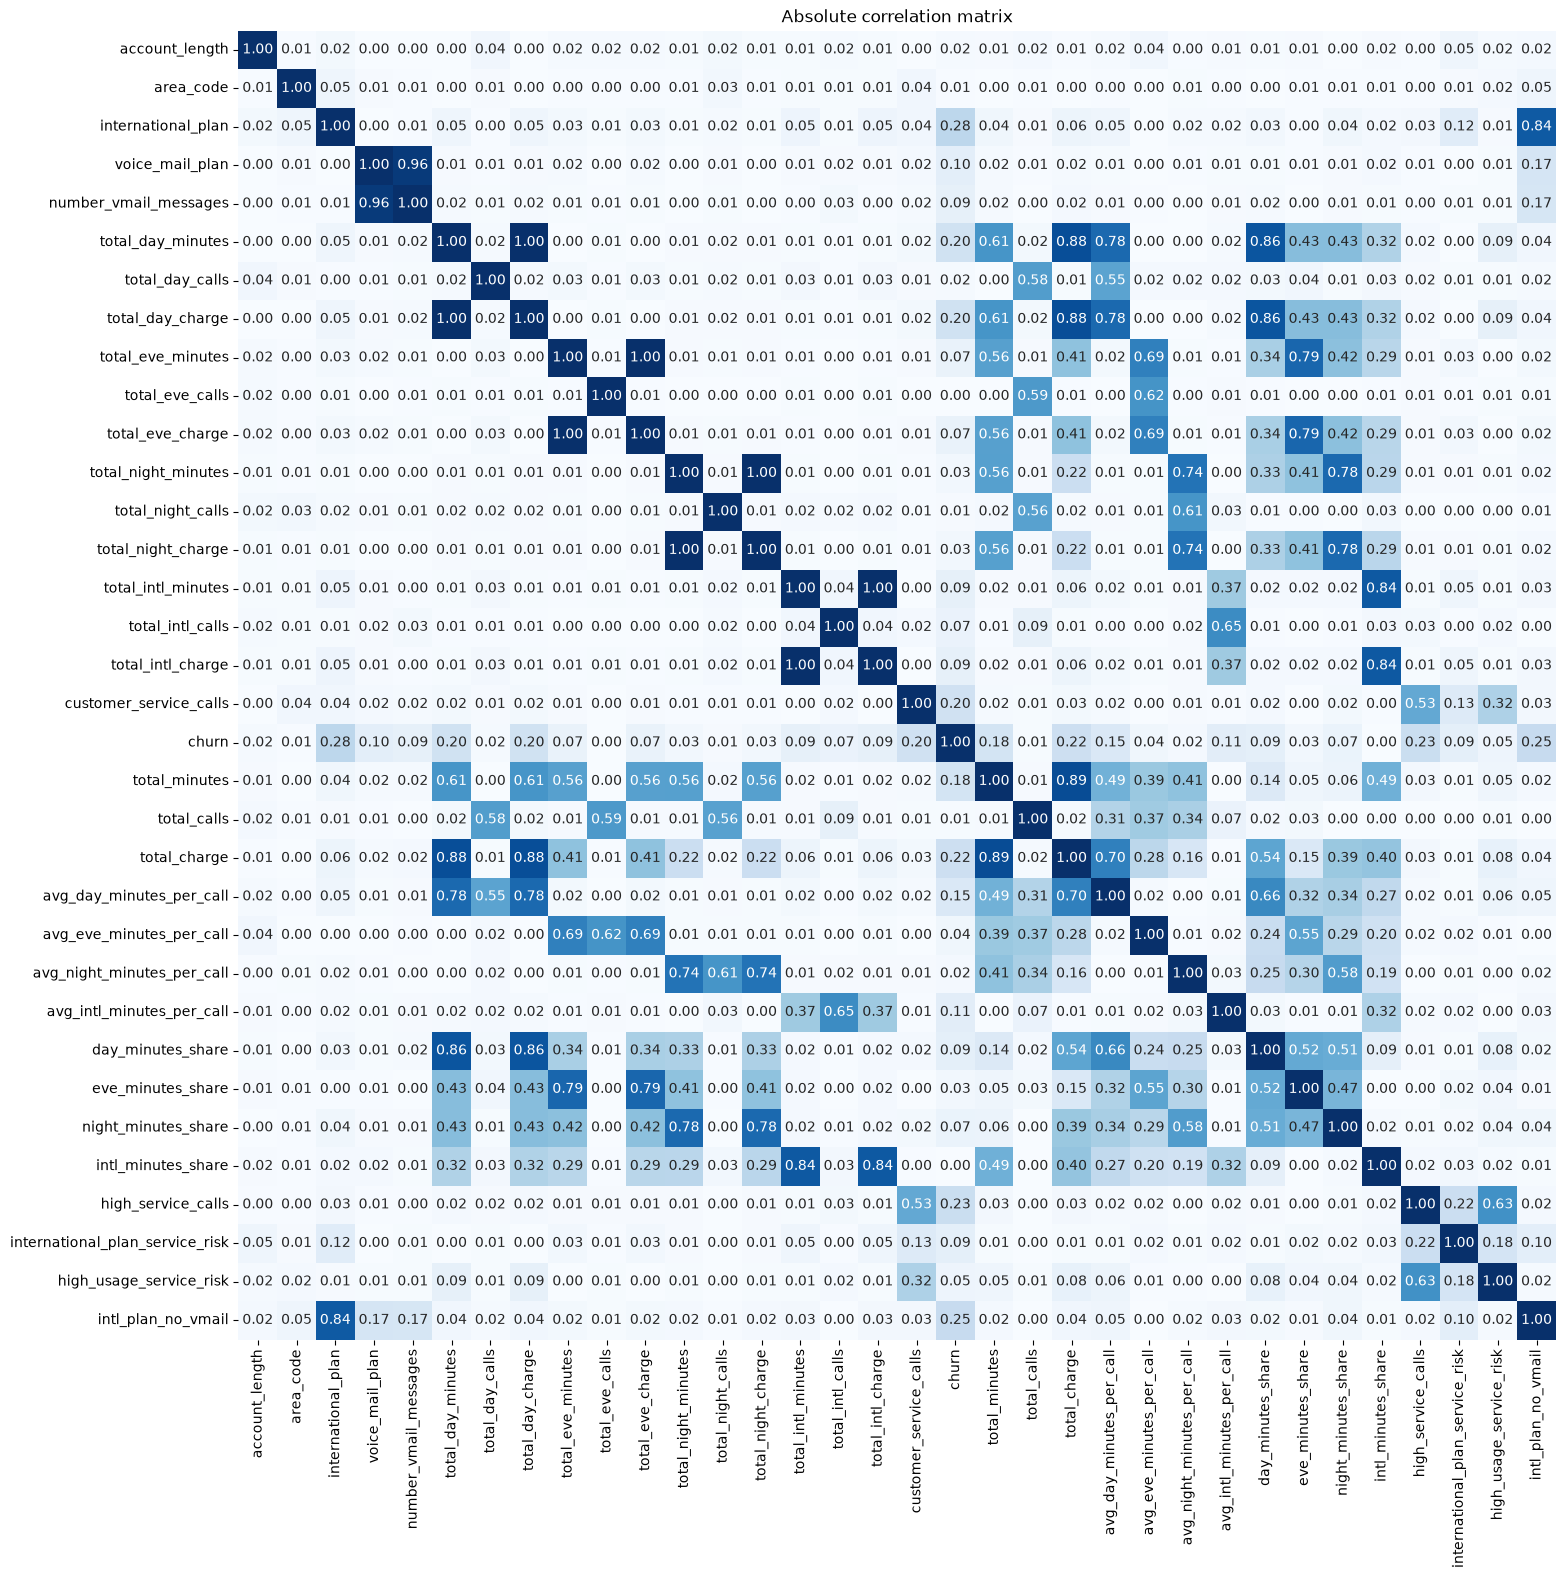

In [19]:
# add customer service and interaction features to the existing dataframe
df = add_customer_service_and_interaction_features(df)

_, ax = plt.subplots(figsize=(17, 17))

sns.heatmap(
    data=abs(df.corr()),
    cmap="Blues",
    annot=True,
    cbar=False,
    fmt=".2f",
)
plt.title("Absolute correlation matrix")
plt.show()

In [20]:
# train and evaluate models on the new data
train_and_evaluate_models(df)

Model: Decision Tree, AUC CV Score: 0.9014237078710764 ± 0.015070743986629881
Model: Decision Tree, Precision CV Score: 0.7853852176079144 ± 0.05539618265602908
Model: Decision Tree, Recall CV Score: 0.8427905427905428 ± 0.02357971572274421
Model: Decision Tree, F1 CV Score: 0.812207705161087 ± 0.03545886191527629
Model: Decision Tree, Accuracy CV Score: 0.9429826225660701 ± 0.012148282423211938
----------------------------------------------------------------------------------------------------
Model: Random Forest, AUC CV Score: 0.9153214964297959 ± 0.012716828446317208
Model: Random Forest, Precision CV Score: 0.9871336313959265 ± 0.019081697279828013
Model: Random Forest, Recall CV Score: 0.8145521145521146 ± 0.03626683985303972
Model: Random Forest, F1 CV Score: 0.8924025957537836 ± 0.029353026885350974
Model: Random Forest, Accuracy CV Score: 0.971498338146735 ± 0.007416440501438234
---------------------------------------------------------------------------------------------------

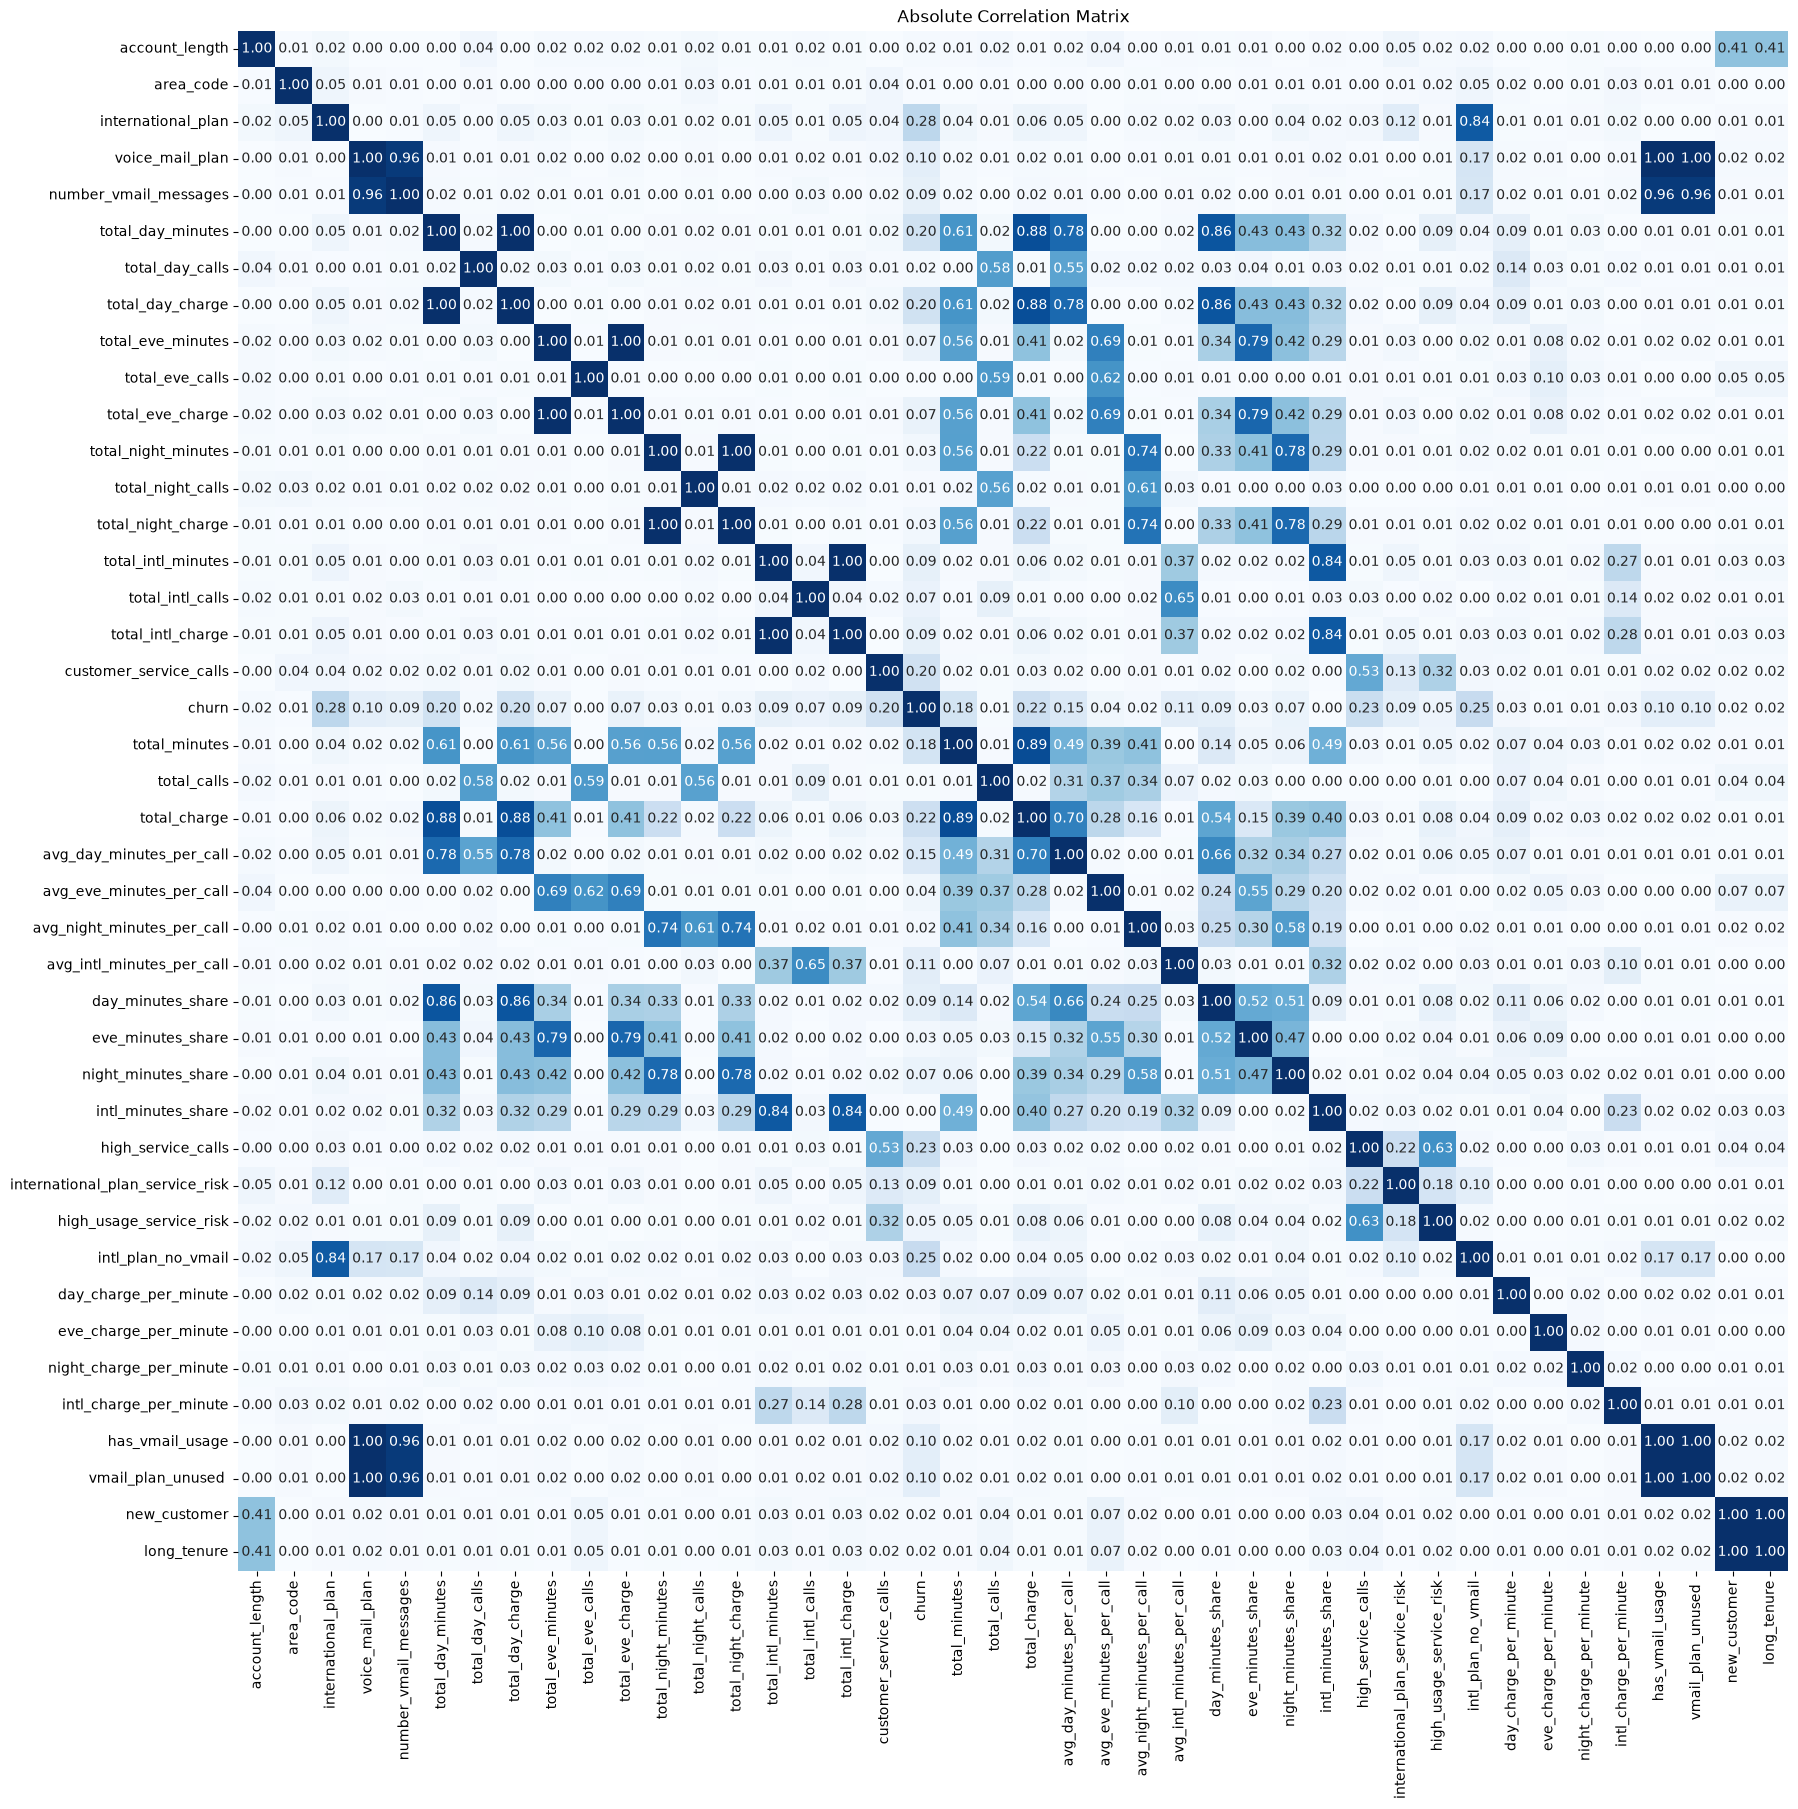

In [21]:
# load the full engineered data
df = get_df_engineered(df)

_, ax = plt.subplots(figsize=(20, 20))

sns.heatmap(
    data=abs(df.corr()),
    cmap="Blues",
    annot=True,
    cbar=False,
    fmt=".2f",
)
plt.title("Absolute Correlation Matrix")
plt.show()

In [22]:
# train and evaluate models on the full engineered data
train_and_evaluate_models(df)

Model: Decision Tree, AUC CV Score: 0.901714820267452 ± 0.012057797067064996
Model: Decision Tree, Precision CV Score: 0.8079456120162316 ± 0.03703337207906329
Model: Decision Tree, Recall CV Score: 0.8376623376623377 ± 0.02368449505921648
Model: Decision Tree, F1 CV Score: 0.8219592732242897 ± 0.022632300338296944
Model: Decision Tree, Accuracy CV Score: 0.9471144184216259 ± 0.007234704622229216
----------------------------------------------------------------------------------------------------
Model: Random Forest, AUC CV Score: 0.9147301809751202 ± 0.012686093140854704
Model: Random Forest, Precision CV Score: 0.9966666666666667 ± 0.006666666666666687
Model: Random Forest, Recall CV Score: 0.8119880119880121 ± 0.03242633382596927
Model: Random Forest, F1 CV Score: 0.8946349717651719 ± 0.02213520454629972
Model: Random Forest, Accuracy CV Score: 0.9722466991307769 ± 0.005464245001903127
--------------------------------------------------------------------------------------------------

In [23]:
# do feature extraction using PCA
X, y = df.drop(columns=['churn']), df['churn']

# split data into train and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

pca = PCA(random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

(-0.5, 40.0)

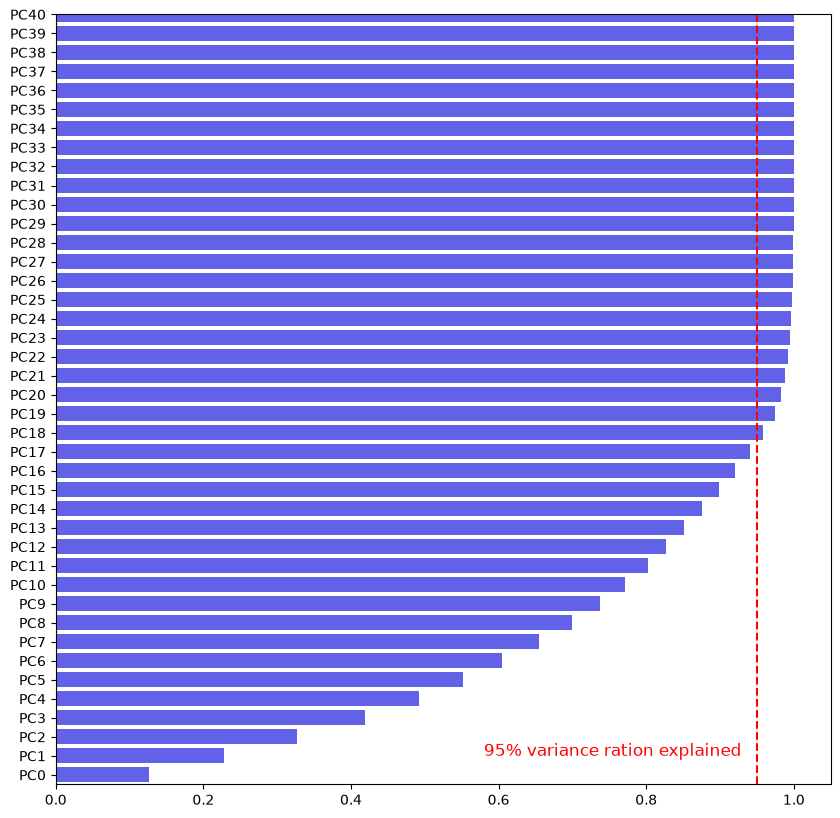

In [24]:
# plot the explained variance ratio
_, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    y=[f"PC{i}" for i in range(pca.n_features_in_)],
    x=np.cumsum(pca.explained_variance_ratio_),
    orient="h",
    color="b",
    alpha=0.7
)
plt.vlines(x=0.95, ymin=-0.5, ymax=40.5, color="r", linestyles="dashed")
plt.text(x=0.58, y=1, s="95% variance ration explained", color="r", fontsize=12)

plt.ylim(-0.5, 40)

In [25]:
# train and evaluate random forest and xgboost models on the pca transformed data
# load data
X_train_pca_095 = X_train_pca[:, :19]
X_val_pca_095 = X_val_pca[:, :19]

# train models
rf = RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=42)
bst = XGBClassifier(n_jobs=-1, random_state=42)

rf.fit(X_train_pca_095, y_train)
bst.fit(X_train_pca_095, y_train)

y_pred_rf = rf.predict(X_val_pca_095)
y_pred_bst = bst.predict(X_val_pca_095)

# evaluate models
print(f"Radnom Forest OOB Score: {rf.oob_score_:.3f}")
print(f"Random Forest F1 Score: {f1_score(y_val, y_pred_rf):.3f}")
print(f"Random Forest Precision Score: {precision_score(y_val, y_pred_rf):.3f}")
print(f"Random Forest Recall Score: {recall_score(y_val, y_pred_rf):.3f}")
print(f"Random Forest Accuracy Score: {accuracy_score(y_val, y_pred_rf):.3f}")
print(f"Random Forest AUC Score: {roc_auc_score(y_val, y_pred_rf):.3f}")
print("-" * 50)

print(f"XGBoost F1 Score: {f1_score(y_val, y_pred_bst):.3f}")
print(f"XGBoost Precision Score: {precision_score(y_val, y_pred_bst):.3f}")
print(f"XGBoost Recall Score: {recall_score(y_val, y_pred_bst):.3f}")
print(f"XGBoost Accuracy Score: {accuracy_score(y_val, y_pred_bst):.3f}")
print(f"XGBoost AUC Score: {roc_auc_score(y_val, y_pred_bst):.3f}")

Radnom Forest OOB Score: 0.928
Random Forest F1 Score: 0.715
Random Forest Precision Score: 1.000
Random Forest Recall Score: 0.557
Random Forest Accuracy Score: 0.934
Random Forest AUC Score: 0.778
--------------------------------------------------
XGBoost F1 Score: 0.783
XGBoost Precision Score: 0.915
XGBoost Recall Score: 0.684
XGBoost Accuracy Score: 0.944
XGBoost AUC Score: 0.836


In [26]:
def train_and_evaluate_models(df: pd.DataFrame) -> None:
	"""
	This function trains and evaluates the models on the given dataframe.

	:param df: Dataframe containing the original data.
	:return: None
	"""
	dt = DecisionTreeClassifier(random_state=42)
	rf = RandomForestClassifier(oob_score=True, random_state=42, n_jobs=-1)
	bst = XGBClassifier(random_state=42, n_jobs=-1)
	models = [dt, rf, bst]
	model_names = ['Decision Tree', 'Random Forest', 'XGBoost']

	X, y = df.drop(columns=['churn']), df['churn']

	scaler = StandardScaler()
	X_scaled = scaler.fit_transform(X)

	pca = PCA(random_state=42)
	X_pca = pca.fit_transform(X_scaled)

	X_pca_095 = X_pca[:, :19]

	kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

	for model, name in zip(models, model_names):
		auc_cv_scores = cross_val_score(model, X_pca_095, y, cv=kfold, scoring='roc_auc')
		precision_cv_scores = cross_val_score(model, X_pca_095, y, cv=kfold, scoring='precision')
		recall_cv_scores = cross_val_score(model, X_pca_095, y, cv=kfold, scoring='recall')
		f1_cv_scores = cross_val_score(model, X_pca_095, y, cv=kfold, scoring='f1')
		accuracy_cv_scores = cross_val_score(model, X_pca_095, y, cv=kfold, scoring='accuracy')

		print(f"Model: {name}, AUC CV Score: {auc_cv_scores.mean()} ± {auc_cv_scores.std()}")
		print(f"Model: {name}, Precision CV Score: {precision_cv_scores.mean()} ± {precision_cv_scores.std()}")
		print(f"Model: {name}, Recall CV Score: {recall_cv_scores.mean()} ± {recall_cv_scores.std()}")
		print(f"Model: {name}, F1 CV Score: {f1_cv_scores.mean()} ± {f1_cv_scores.std()}")
		print(f"Model: {name}, Accuracy CV Score: {accuracy_cv_scores.mean()} ± {accuracy_cv_scores.std()}")
		print("--" * 50)

train_and_evaluate_models(df)

Model: Decision Tree, AUC CV Score: 0.7903235799288431 ± 0.012095961569007191
Model: Decision Tree, Precision CV Score: 0.6477361292425927 ± 0.04477521132427959
Model: Decision Tree, Recall CV Score: 0.6416583416583417 ± 0.039235918794812336
Model: Decision Tree, F1 CV Score: 0.6421537429752784 ± 0.012434751965677083
Model: Decision Tree, Accuracy CV Score: 0.8957304776159256 ± 0.009600559243894463
----------------------------------------------------------------------------------------------------
Model: Random Forest, AUC CV Score: 0.9006103787126054 ± 0.02133543423356592
Model: Random Forest, Precision CV Score: 0.9298754011945501 ± 0.027568915379045187
Model: Random Forest, Recall CV Score: 0.5953379953379953 ± 0.03237845649452492
Model: Random Forest, F1 CV Score: 0.7247897009761877 ± 0.017340938280163327
Model: Random Forest, Accuracy CV Score: 0.9343578500607823 ± 0.002670576536159422
------------------------------------------------------------------------------------------------

In [27]:
# feature selection based-on the importance of each feature
rf = RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=42)

pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("rf", rf)
	]
)

param_grid = {
    "rf__n_estimators": [10, 300, 500, 800],
    "rf__max_depth": [5, 10, 20]
}
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=make_scorer(f1_score),
    cv=kfold,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X, y)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/home/erfan_taherirani/miniconda3/envs/mlenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/erfan_taherirani/miniconda3/envs/mlenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/erfan_taherirani/miniconda3/envs/mlenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/erfan_taherirani/miniconda3/envs/mlenv/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/erfan_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__max_depth': [5, 10, ...], 'rf__n_estimators': [10, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_example

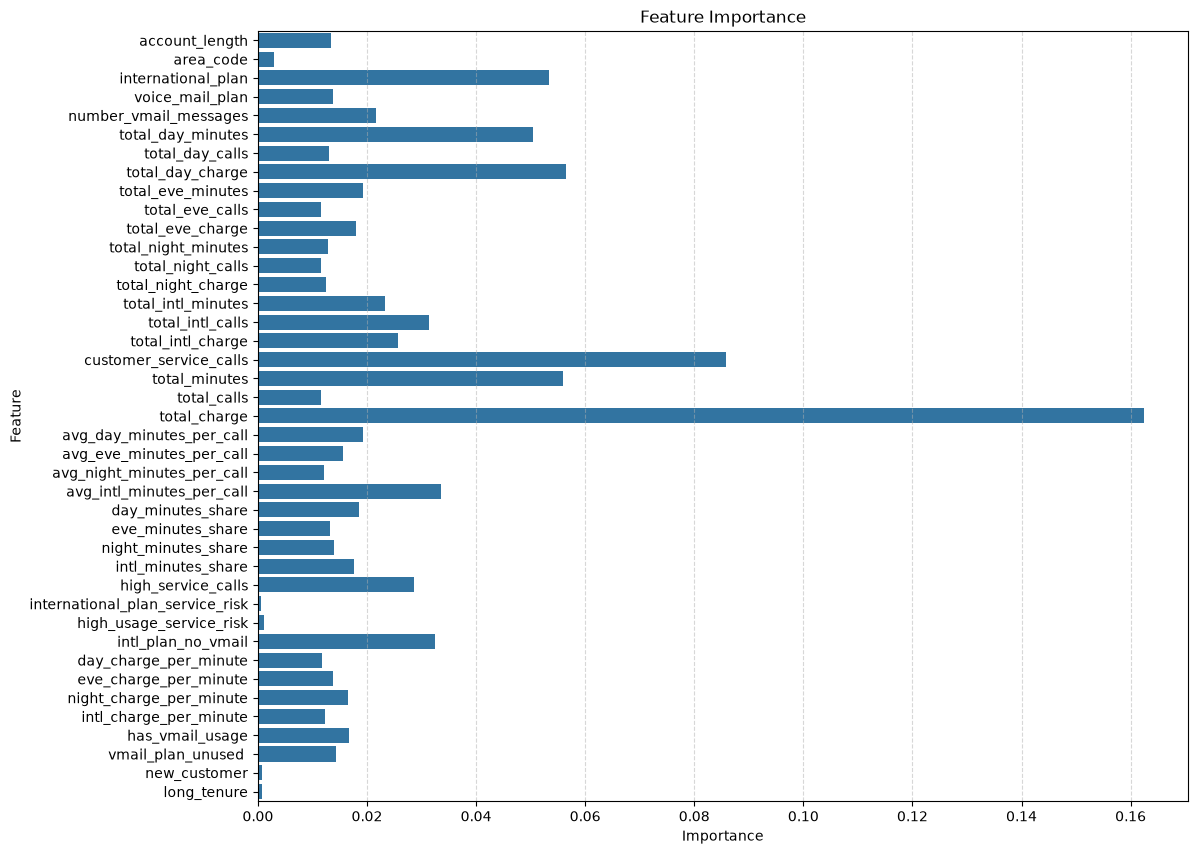

In [28]:
_, ax = plt.subplots(figsize=(12, 10))

sns.barplot(
    y=X.columns,
    x=grid.best_estimator_.named_steps['rf'].feature_importances_,
    orient='h',
    ax=ax
)
ax.set(
    title='Feature Importance',
    xlabel='Importance',
    ylabel='Feature'
)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

<Axes: >

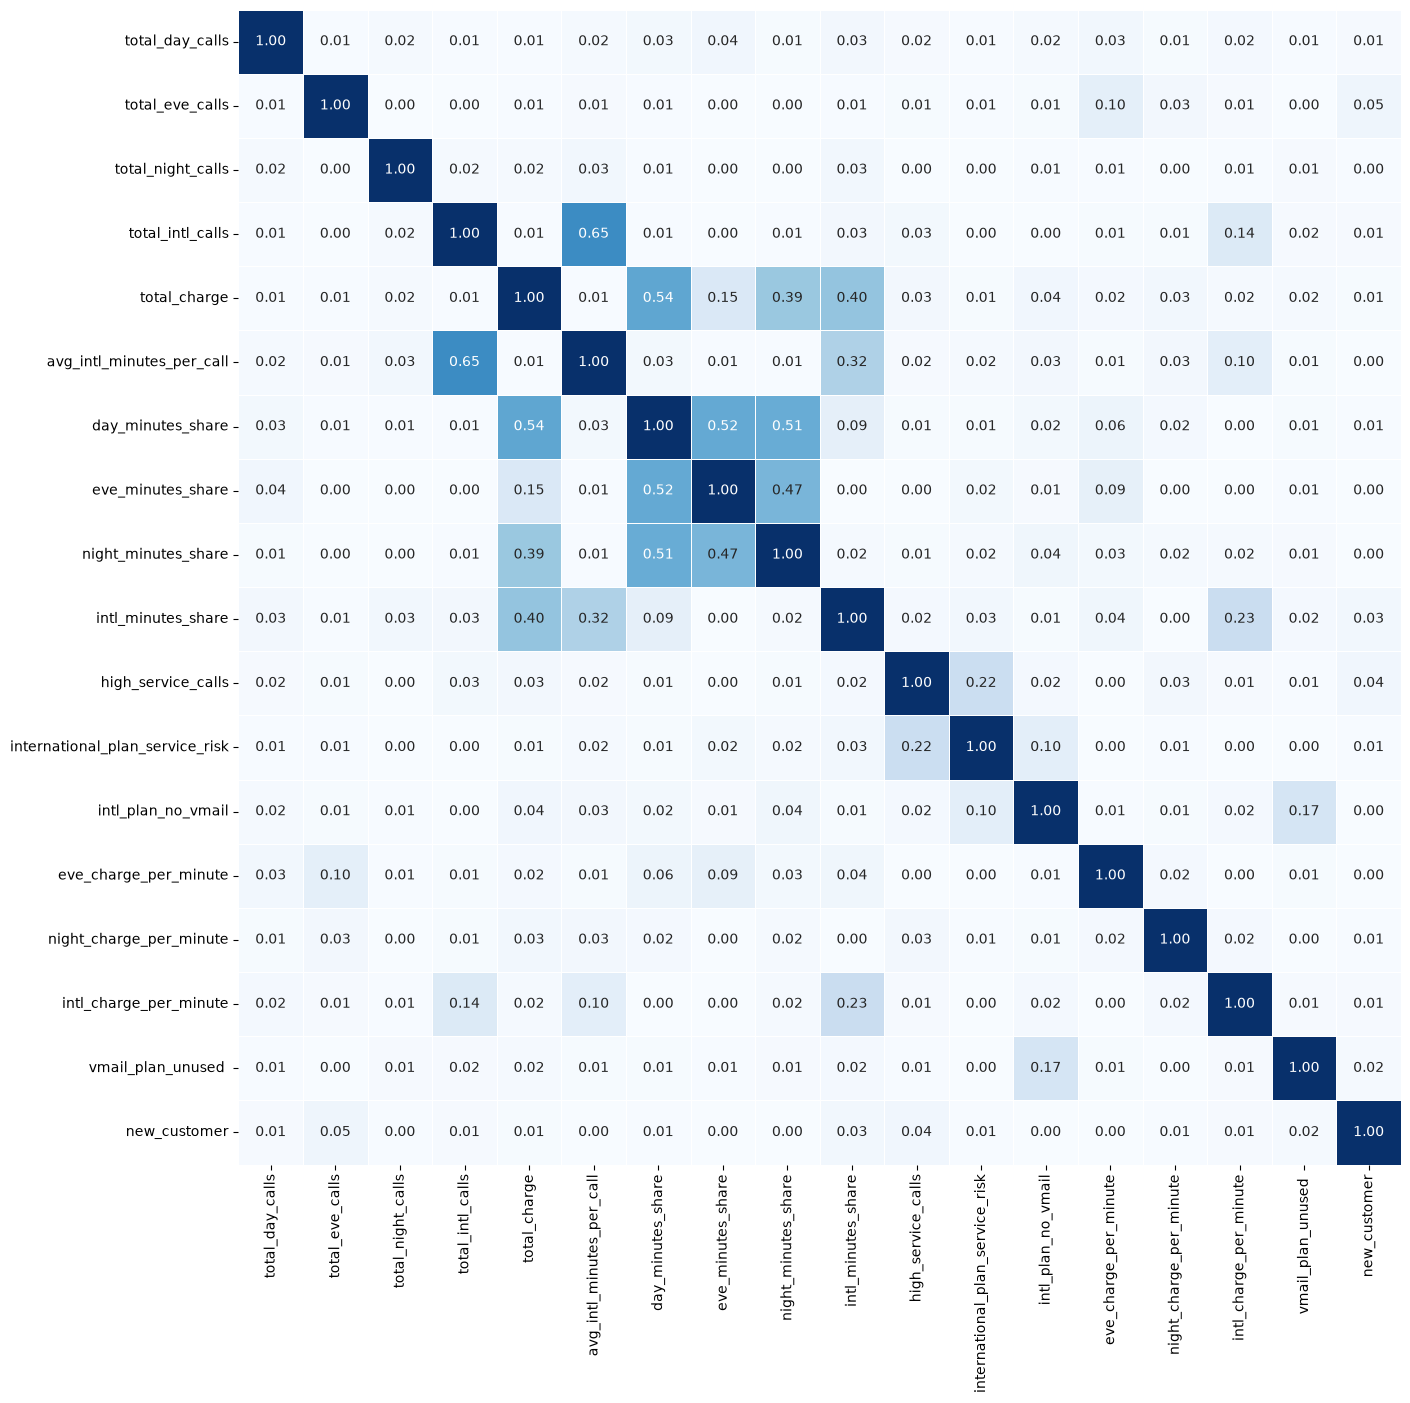

In [29]:
features_argsort = grid.best_estimator_.named_steps['rf'].feature_importances_.argsort()
selected_features = []
for i, feature_importance_rank in enumerate(features_argsort):
    if feature_importance_rank <= 25:
        selected_features.append(i)

X_selected = X.iloc[:, selected_features]
X_selected.drop(columns=[
    "total_day_charge",
    "total_day_minutes",
    "has_vmail_usage",
	"long_tenure",
    "total_night_charge",
	"total_intl_charge",
    "total_night_minutes",
    "number_vmail_messages",
], inplace=True)

_, ax = plt.subplots(figsize=(15, 15))

sns.heatmap(
    data=abs(X_selected.corr()),
    annot=True,
    cmap='Blues',
    fmt='.2f',
    cbar=False,
    linewidths=0.5,
)

In [30]:
# model training
bst = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1)
scaler = StandardScaler()

pipe = Pipeline(
    steps=[
        ("scaler", scaler),
        ("bst", bst)
    ]
)
pipe.fit(X_selected, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('bst', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['total_day_calls','total_eve_calls','total_night_calls',..., 'intl_charge_per_minute','vmail_plan_unused ','new_customer']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [31]:
param_grid = {
    "bst__n_estimators": [100, 300, 700],
    "bst__max_depth": [None, 5, 20, 40]
}

grid_bst = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1,
)
grid_bst.fit(X_selected, y)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bst__max_depth': [None, 5, ...], 'bst__n_estimators': [100, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_p

In [32]:
grid_bst.best_params_

{'bst__max_depth': 5, 'bst__n_estimators': 100}

In [33]:
pipe.set_params(bst__n_estimators=100, bst__max_depth=5)
pipe.fit(X_selected, y)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

for metric in metrics:
    cv_scores = cross_val_score(pipe, X, y, cv=kfold, scoring=metric, n_jobs=-1)
    print(f"{metric}: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

accuracy: 0.975 ± 0.004
precision: 0.988 ± 0.006
recall: 0.840 ± 0.025
f1: 0.908 ± 0.016
roc_auc: 0.925 ± 0.014


In [34]:
# full pipeline of modeling:

# load train data
df = pd.read_csv("../data/processed/df_processed.csv")

bst = train_model(df, 'churn') # train model
bst

Training Scores:

accuracy: 0.9778710008361967 +/- 0.002742704354361818
precision: 0.9911299697744711 +/- 0.007245469118540134
recall: 0.8557442557442558 +/- 0.01830853879873677
f1: 0.9183464482971873 +/- 0.010556645928547416
roc_auc: 0.9137763585941723 +/- 0.005987729103419791


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('bst', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['account_length','area_code','international_plan',...,'total_minutes', 'total_calls','total_charge']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


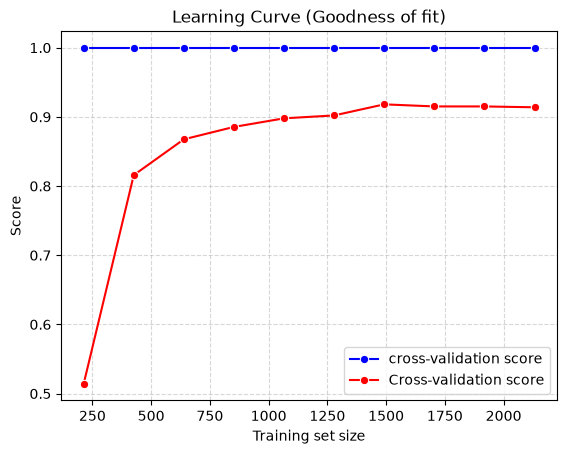

In [35]:
def plot_learning_curve(df: pd.DataFrame):
	df = add_aggregate_usage_features(df)
	X, y = df.drop(columns=['churn']), df['churn']

	kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

	train_sizes, train_scores, test_scores = learning_curve(
		estimator=bst,
		X=X,
		y=y,
		train_sizes=np.linspace(0.1, 1.0, 10),
		scoring='f1',
		cv=kfold,
		n_jobs=-1,
	)

	sns.lineplot(
		x=train_sizes,
		y=train_scores.mean(axis=1),
		label='cross-validation score',
		color='b',
		marker='o',
	)
	sns.lineplot(
		x=train_sizes,
		y=test_scores.mean(axis=1),
		label='Cross-validation score',
		color='r',
		marker='o',
	)
	plt.title('Learning Curve (Goodness of fit)')
	plt.xlabel('Training set size')
	plt.ylabel('Score')
	plt.legend(loc='best')
	plt.grid(True, linestyle='--', alpha=0.5)
	plt.show()

plot_learning_curve(df)

In [39]:
def evaluate_model(model: XGBClassifier, df_test: pd.DataFrame) -> None:
    """
    This function evaluates the model on the test dataset.

    :param model: The trained model.
    :param df_test: The test dataset.
    :return: None
    """
    df_test = add_aggregate_usage_features(df_test)
    X = df_test.drop(columns=["churn"])
    y = df_test["churn"]

	# evaluate model
    y_pred = model.predict(X)
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred)

	print("Test Scores:\n")
    print(f"Accuracy: {accuracy * 100:.1f}%")
    print(f"Precision: {precision * 100:.1f}%")
    print(f"Recall: {recall * 100:.1f}%")
    print(f"F1 Score: {f1 * 100:.1f}%")
    print(f"ROC AUC: {roc_auc * 100:.1f}%")
    


df_test = pd.read_csv("../data/processed/df_test_processed.csv")
evaluate_model(bst, df_test)

TabError: inconsistent use of tabs and spaces in indentation (<string>, line 21)

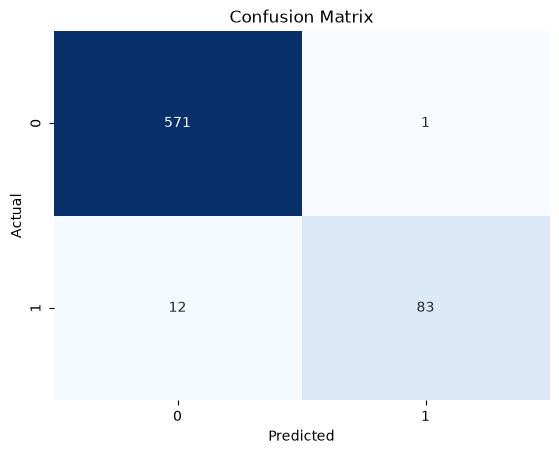

In [37]:
def plot_confusion_matrix(estimator, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        data=cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
	)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

df_test = add_aggregate_usage_features(df_test)
X_test = df_test.drop(columns=["churn"])
y_test = df_test["churn"]

y_pred = bst.predict(X_test)
plot_confusion_matrix(bst, y_test, y_pred)

In [38]:
save_estimator(estimator=bst, file_path="../models/xgboost_classifier.pkl")

Model saved to ../models/xgboost_classifier.pkl
